In [ ]:
def z_from_slice(slice):
    lamda0 = 1215.670
    lamda = 3470 + (slice - 1.) * 2.
    z = (lamda - lamda0) / lamda0
    
    return z

In [ ]:
# Column names
COL_RA = "RA"
COL_DEC = "DEC"
COL_z = "z"
out_dir = "/data/hetdex/u/bgrashey/data_/"        
name = "test.fits"

from astropy.table import Table
import os
import numpy as np
from tools.EW import Measurements
from astropy.io import fits
from astropy.coordinates import SkyCoord

# catalog:
table_path = "/data/hetdex/u/bgrashey/data_/missing_mawatari_sources.fits"    
tbl = Table.read(table_path)
Catalog = tbl.to_pandas()
Catalog = Catalog.reset_index(drop=True)

directory = "/data/hetdex/u/mxhf/VDFI/VirusDeep/stackmf/ssa22_fullfp/"
file_stack = "ssa22_fullfp_stack.fits"
stack = os.path.join(directory, file_stack)
cube = fits.open(stack, memmap=True)
data = cube[0].section
header = cube[0].header

hsc_file = "/data/hetdex/u/mxhf/VDFI/joint/ssa22_hsc_pdr3_wide.fits"
with fits.open(hsc_file) as hdul:
    hsc_df = Table(hdul[1].data).to_pandas()
hsc_coords = SkyCoord(ra=hsc_df["ra"].values, 
                      dec=hsc_df["dec"].values, 
                      unit="deg", frame="icrs")        

# Neue Spalten als Listen initialisieren
new_cols = {
    "REDSHIFT": [], "EW": [], "EW_OBS": [], "EW_ERR": [],
    "FLUX": [], "FLUX_ERR": [], "CONT": [], "CONT_ERR": []
}

N = len(Catalog[COL_RA])
for n in range(N):
    print(f"\nInitialising Object {n+1}/{N}")
    
    try:
        coords = (
            Catalog[COL_RA][n],
            Catalog[COL_DEC][n],
            Catalog[COL_z][n]
        )
        
        meas = Measurements(data, header, coords, hsc_df, hsc_coords)
        EW_OBS, EW, EW_ERR, F, F_ERR, C, C_ERR, z = meas.measure_ew()
        
        new_cols["REDSHIFT"].append(z)
        new_cols["EW"].append(EW)
        new_cols["EW_OBS"].append(EW_OBS)
        new_cols["EW_ERR"].append(EW_ERR)
        new_cols["FLUX"].append(F)
        new_cols["FLUX_ERR"].append(F_ERR)
        new_cols["CONT"].append(C)
        new_cols["CONT_ERR"].append(C_ERR)
        
        print("done")
    
    except Exception as e:
        print(f"Object {n} failed: {e}")
        for key in new_cols:
            new_cols[key].append(np.nan)

# Neue Spalten an den originalen Katalog hängen
for col_name, values in new_cols.items():
    tbl[col_name] = np.array(values, dtype="f8")

# Klassifikations-Wahrscheinlichkeit berechnen
from line_classifier.probs.classification_prob import source_prob
import configparser

config_file = "/data/hetdex/u/bgrashey/notebooks/line_prob/hetdex_line_classification/tests/data/universe.cfg"
flim_file = "/data/hetdex/u/bgrashey/notebooks/Line_flux_limit_5_sigma_baseline.dat"

config = configparser.ConfigParser()
config.read(config_file)

z   = tbl["REDSHIFT"]
F   = tbl["FLUX"]
E   = tbl["FLUX_ERR"]
eq  = tbl["EW_OBS"]
eq_E = tbl["EW_ERR"]

p = source_prob(config, [1]*len(z), [1]*len(z), z, F, E, eq, eq_E,
                None, None, None, None, None, flim_file, ignore_noise=True)
tbl["PROB"] = p

out_path = os.path.join(out_dir, name)
tbl.write(out_path, overwrite=True)

cube.close()

In [ ]:
print("done")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.io import fits
from math import ceil

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
Z_REF = 2.7

def slice_from_z(z):
    crpix = 1
    crval = 3470. 
    cdelt = 2.
    obs_wave = 1216 * (1. + z)
    slice_idx = crpix + (obs_wave - crval) / cdelt
    return slice_idx

def scale_params(z, flux, sigma):
    Z_REF = 2.7
    DL = cosmo.luminosity_distance(Z_REF).value
    DA = cosmo.angular_diameter_distance(Z_REF).value

    dl = cosmo.luminosity_distance(z).value
    da = cosmo.angular_diameter_distance(z).value

    flux_scaled = flux * (DL / dl)**2
    sigma_scaled = sigma * (DA / da)

    return flux_scaled, sigma_scaled

def generate_source_stamp(x0, y0, z, theta, flux, sigma, sigma_lam, elipticity):
    """
    sigma: Width in pixels
    sigma_lam: Width of the emission line in AA
    """
    pad_spat = int(ceil(sigma * 5))
    
    cdelt = 2.0
    sig_lam_pix = (sigma_lam / cdelt) / 2.355
    pad_spec = int(ceil(sig_lam_pix * 5))

    z_axis = np.arange(-pad_spec, pad_spec + 1)
    y_axis = np.arange(-pad_spat, pad_spat + 1)
    x_axis = np.arange(-pad_spat, pad_spat + 1)
    z_grid, y_grid, x_grid = np.ix_(z_axis, y_axis, x_axis)

    theta_rad = np.radians(theta)
    x_rot = x_grid * np.cos(theta_rad) + y_grid * np.sin(theta_rad)
    y_rot = -x_grid * np.sin(theta_rad) + y_grid * np.cos(theta_rad)

    flux, sigma = scale_params(z, flux, sigma)
    
    a = sigma
    b = sigma * elipticity

    spatial = np.exp(-( (x_rot**2 / (2 * a**2)) + (y_rot**2 / (2 * b**2)) ))
    spectral = np.exp(-(z_grid**2 / (2 * sig_lam_pix**2)))

    stamp = spatial * spectral
    total_sum = np.sum(stamp)
    
    if total_sum > 0:
        scaled_stamp = (stamp / total_sum) * flux
    else:
        scaled_stamp = np.zeros_like(stamp)

    return scaled_stamp.astype(np.float32), pad_spec, pad_spat

def save_cube_fits(cube, outpath, header_params=None):
    hdu = fits.PrimaryHDU(cube.astype(np.float32))
    if header_params:
        for key, value in header_params.items():
            hdu.header[key] = value
    hdu.writeto(outpath, overwrite=True)
    print(f"Cube saved to {outpath}")

def create_mock_cube(n_sources, data_shape):
    nz, ny, nx = data_shape

    full_cube = np.zeros((nz, ny, nx), dtype=np.float32)
    full_cube += np.random.normal(0, 0.08, full_cube.shape).astype(np.float32)
    
    catalog = []

    for i in range(n_sources):
        x = np.random.uniform(0, nx)
        y = np.random.uniform(0, ny)
        z = np.random.uniform(1.9, 3.4)
        flux = np.random.uniform(100, 528)
        theta = np.random.uniform(0, 360)
        sigma = np.random.uniform(4, 15)
        sigma_lam = 10
        elipticity = np.random.uniform(0.7, 1)

        stamp, p_spec, p_spat = generate_source_stamp(x, y, z, theta, flux, sigma, 
                                                       sigma_lam, elipticity)

        z_pix = int(round(slice_from_z(z)))
        
        z_min, z_max = z_pix - p_spec, z_pix + p_spec + 1
        y_min, y_max = int(round(y)) - p_spat, int(round(y)) + p_spat + 1
        x_min, x_max = int(round(x)) - p_spat, int(round(x)) + p_spat + 1

        z_s_cube, z_e_cube = max(0, z_min), min(nz, z_max)
        y_s_cube, y_e_cube = max(0, y_min), min(ny, y_max)
        x_s_cube, x_e_cube = max(0, x_min), min(nx, x_max)

        z_s_stmp, z_e_stmp = z_s_cube - z_min, z_e_cube - z_min
        y_s_stmp, y_e_stmp = y_s_cube - y_min, y_e_cube - y_min
        x_s_stmp, x_e_stmp = x_s_cube - x_min, x_e_cube - x_min

        if (z_e_cube > z_s_cube and y_e_cube > y_s_cube and x_e_cube > x_s_cube):
            full_cube[z_s_cube:z_e_cube, y_s_cube:y_e_cube, x_s_cube:x_e_cube] += \
                stamp[z_s_stmp:z_e_stmp, y_s_stmp:y_e_stmp, x_s_stmp:x_e_stmp]
            
            catalog.append([i, x, y, z, flux])

    return full_cube, catalog


def inject_sources_into_cube(existing_cube, wcs, n_sources, existing_catalog, matching_radius_arcsec=2.0):
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    nz, ny, nx = existing_cube.shape
    new_sources_catalog = []
    
    axis_types = wcs.get_axis_types()
    ra_ax, dec_ax, wave_ax = None, None, None
    
    for i, ax in enumerate(axis_types):
        if ax['coordinate_type'] is None:
            continue
        if ax['coordinate_type'] == 'celestial':
            if ax['number'] == 0:
                ra_ax = i
            elif ax['number'] == 1:
                dec_ax = i
        elif ax['coordinate_type'] == 'spectral':
            wave_ax = i

    if ra_ax is None or dec_ax is None or wave_ax is None:
        raise ValueError("Das WCS-Objekt enthält keine eindeutigen RA-, DEC- oder Wellenlängen-Achsen.")

    # KD-Tree einmal aufbauen
    existing_coords = SkyCoord(
        ra=[src[0] for src in existing_catalog] * u.deg,
        dec=[src[1] for src in existing_catalog] * u.deg
    )
    existing_z = np.array([src[2] for src in existing_catalog])

    matching_radius_deg = matching_radius_arcsec / 3600.0

    for i in range(n_sources):
        z = np.random.uniform(1.9, 3.4)
        flux = np.random.uniform(100, 528)
        theta = np.random.uniform(0, 360)
        sigma = np.random.uniform(4, 15)
        sigma_lam = 10
        elipticity = np.random.uniform(0.7, 1)

        x_pix = np.random.uniform(sigma * 5, nx - sigma * 5)
        y_pix = np.random.uniform(sigma * 5, ny - sigma * 5)
        z_pix = slice_from_z(z)

        pix_coords = [None, None, None]
        pix_coords[ra_ax] = x_pix
        pix_coords[dec_ax] = y_pix
        pix_coords[wave_ax] = z_pix
        
        world_coords = wcs.all_pix2world([pix_coords], 0)[0]
        ra_val = world_coords[ra_ax]
        dec_val = world_coords[dec_ax]

        # Schneller Abgleich per SkyCoord
        new_coord = SkyCoord(ra=ra_val * u.deg, dec=dec_val * u.deg)
        sep = new_coord.separation(existing_coords).arcsec
        close_mask = sep < matching_radius_arcsec
        already_exists = np.any(close_mask & (np.abs(existing_z - z) < 0.05))

        if already_exists:
            print(f"Quelle bei RA: {ra_val:.4f}, DEC: {dec_val:.4f} übersprungen (existiert bereits).")
            continue

        stamp, p_spec, p_spat = generate_source_stamp(
            x_pix, y_pix, z, theta, flux, sigma, sigma_lam, elipticity
        )

        z_int, y_int, x_int = int(round(z_pix)), int(round(y_pix)), int(round(x_pix))
        
        z_min, z_max = z_int - p_spec, z_int + p_spec + 1
        y_min, y_max = y_int - p_spat, y_int + p_spat + 1
        x_min, x_max = x_int - p_spat, x_int + p_spat + 1

        z_s_cube, z_e_cube = max(0, z_min), min(nz, z_max)
        y_s_cube, y_e_cube = max(0, y_min), min(ny, y_max)
        x_s_cube, x_e_cube = max(0, x_min), min(nx, x_max)

        z_s_stmp, z_e_stmp = z_s_cube - z_min, z_e_cube - z_min
        y_s_stmp, y_e_stmp = y_s_cube - y_min, y_e_cube - y_min
        x_s_stmp, x_e_stmp = x_s_cube - x_min, x_e_cube - x_min

        if (z_e_cube > z_s_cube and y_e_cube > y_s_cube and x_e_cube > x_s_cube):
            existing_cube[z_s_cube:z_e_cube, y_s_cube:y_e_cube, x_s_cube:x_e_cube] += \
                stamp[z_s_stmp:z_e_stmp, y_s_stmp:y_e_stmp, x_s_stmp:x_e_stmp]
            
            new_sources_catalog.append([i, ra_val, dec_val, z, flux])

    return existing_cube, new_sources_catalog

In [ ]:
fits_header = {
    # Struktur-Keys (SIMPLE, BITPIX, NAXIS) wurden entfernt, 
    # da astropy sie automatisch aus dem numpy-Array generiert.
    
    # Achse 1 (RA)
    "CTYPE1": "RA---TAN",
    "CRPIX1": 1154.0,
    "CRVAL1": 334.3046148580798,
    "CDELT1": -0.00013888888888888,
    "CUNIT1": "deg",
    
    # Achse 2 (DEC)
    "CTYPE2": "DEC--TAN",
    "CRPIX2": 1244.0,
    "CRVAL2": 0.27905188201479886,
    "CDELT2": 0.000138888888888888,
    "CUNIT2": "deg",
    
    # Achse 3 (Wellenlänge)
    "CTYPE3": "WAVE",  # Geändert von "Wave" zu "WAVE" für WCS-Konformität
    "CRPIX3": 1.0,
    "CRVAL3": 3470.0,
    "CDELT3": 2.0,
    "CUNIT3": "Angstrom",
    
    # Zusätzliche Metadaten
    "INSTRUME": "KCWI"
}

In [ ]:
from astropy.wcs import WCS
from astropy.io import fits
from astropy.table import Table
import numpy as np

with fits.open("../cubes/ssa22_fullfp_stack.fits") as hdul:
    wcs = WCS(hdul[0].header)
    cube = hdul[0].data.astype(np.float32)
    
wcs.wcs.ctype = ['RA---TAN', 'DEC--TAN', 'WAVE']
wcs.wcs.set()

cat = Table.read("../data_/combined_manual_vdfi_rfscored.fits")

existing_catalog = [[row["ra_vdfi"], row["dec_vdfi"], row["z_vdfi"]] for row in cat]

modified_cube, new_catalog = inject_sources_into_cube(
    existing_cube=cube.copy(),
    wcs=wcs,
    n_sources=10000,
    existing_catalog=existing_catalog,
    matching_radius_arcsec=2.0
)

save_cube_fits(
    cube=modified_cube,
    outpath="../cubes/test.fits",
    header_params=fits_header
)

new_catalog_array = np.array(new_catalog)

out_table = Table(
    [new_catalog_array[:, 0].astype(int),
     new_catalog_array[:, 1],
     new_catalog_array[:, 2],
     new_catalog_array[:, 3],
     new_catalog_array[:, 4]],
    names=["id", "ra", "dec", "z", "flux"]
)

out_table.write("../data_/injected_sources.fits", overwrite=True)

In [ ]:
print("done")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Lade Cube: ../cubes/test.fits
  Shape: (1036, 2478, 2260)
  Erzeuge 10 Cutouts ...


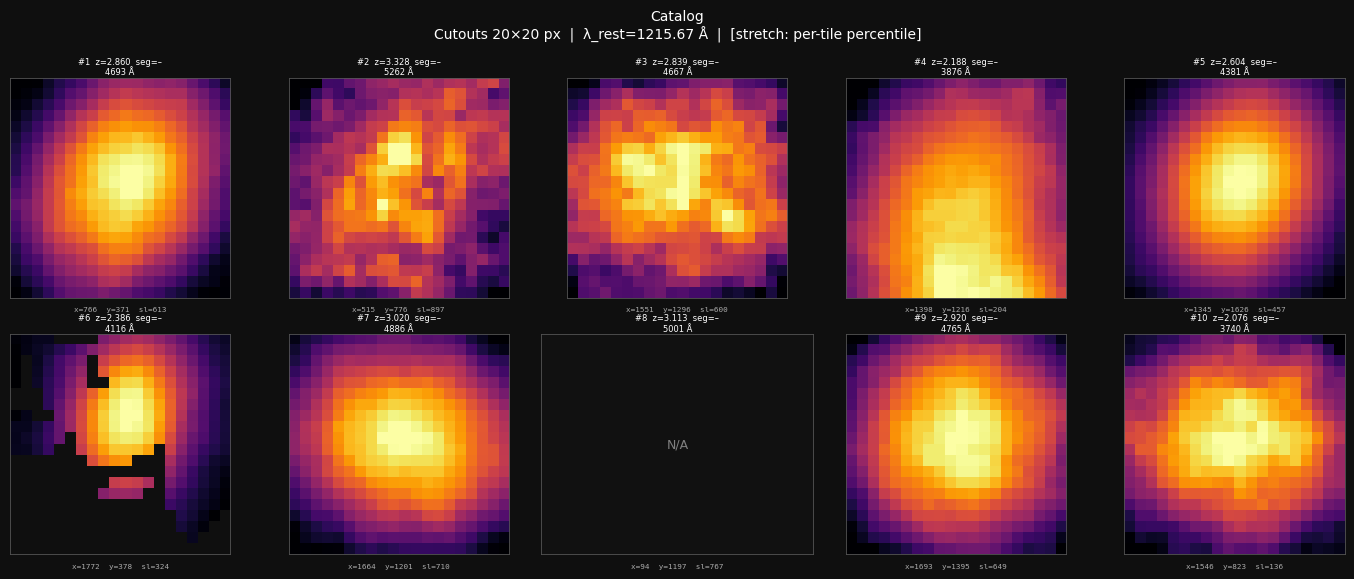

  Gespeichert: ./test_cutouts.pdf


In [8]:
%load_ext autoreload
%autoreload 2

from tools.functions import plot_cutout_grid
from astropy.table import Table

cube = "../cubes/test.fits"
missed = Table.read("../data_/injected_sources.fits")

plot_cutout_grid(
     missed,
     cube,
     "./test_cutouts.pdf",
     col_ra = "ra",
     col_dec = "dec",
     cutout_size = 20,
     num_cutouts = 10,
     use_fixed_stretch = False,
     vmin_fixed      = -300,
     vmax_fixed      =  300,
     cmap            = "inferno",
 )

In [2]:
def redshift_to_slice(redshift):
        lya_obs = 1216.0 * (1.0 + redshift)
        slice_ = round(1 + (lya_obs - 3470) / 2)
        return slice_


In [5]:
print(redshift_to_slice(2.1))

151


In [9]:
import zarr
import numpy as np
from astropy.io import fits

def fits_ifu_to_zarr(fits_path, zarr_path, chunks=(100, 128, 128)):
    root = zarr.open_group(zarr_path, mode="w")

    with fits.open(fits_path) as hdul:
        for i, hdu in enumerate(hdul):
            if hdu.data is None:
                continue
            name = hdu.name or f"ext_{i}"
            
            # Chunks nur für 3D-Würfel anpassen, sonst auto
            c = chunks if hdu.data.ndim == 3 else "auto"
            
            arr = root.create_array(
                name,
                data=hdu.data,
                chunks=c,
                compressors=None,
            )
            arr.attrs["fits_header"] = dict(hdu.header)
            print(f"  {name}: {hdu.data.shape}, chunks={arr.chunks}")

    print(zarr.open(zarr_path).tree())

In [1]:
from tools.cubes import fits_ifu_to_zarr

fits_ifu_to_zarr("/data/hetdex/u/bgrashey/cubes/test.fits", "/data/hetdex/u/bgrashey/cubes/test.zarr")

KeyboardInterrupt: 

In [1]:
import zarr
import dask
import dask.array as da
from astropy.wcs import WCS
from astropy.io import fits

from tools.fof_min import fof_minimal_zarr, catalog_to_wcs_table

sn_cube_path = "/data/hetdex/u/bgrashey/cubes/ssa22_fullfp_sig_filter.zarr"
fits_header_path = "/data/hetdex/u/bgrashey/cubes/ssa22_fullfp_stack.fits"
output_catalog_path = "../cubes/gefundene_quellen.fits"
sn_threshold = 0.75
linking_length = 1.5


sn_cube = da.from_zarr(sn_cube_path, read_only=True)

binary_mask = sn_cube > sn_threshold

catalog_delayed = fof_minimal_zarr(binary_mask, linking_length=linking_length)

cat_computed = dask.compute(catalog_delayed)[0]

header = fits.getheader(fits_header_path)

final_table = catalog_to_wcs_table(cat_computed, wcs_header=header)

final_table.write(output_catalog_path, overwrite=True)

print(f"Fertig: {len(final_table)} Quellen und '{output_catalog_path}' gespeichert.")

1. Öffne S/N-Cube...
2. Generiere die Binärmaske (Thresholding)...
3. Erstelle FoF-Rechengraphen...
4. Berechne Cluster via Dask (das triggert die parallele Ausführung)...
5. Lade WCS-Header für Koordinaten-Transformation...
6. Wandle Pixeldaten in Himmelskoordinaten (RA/DEC/Wellenlänge) um...
7. Speichere finalen Positions-Katalog...
Fertig! 1011857 Quellen gefunden und in '../cubes/gefundene_quellen.fits' gespeichert.


In [2]:
print("done")

done
